# Week 3c — Forecast Evaluation & Model Comparison

**Goal:** Measure how good the moving-average baseline and ARIMA forecasts are
using two standard error metrics — **MAPE** and **RMSE** — both overall and
per product category, and decide which model wins where.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

BASELINE_PATH = Path('..') / 'data' / 'processed' / 'baseline_forecast.csv'
ARIMA_PATH = Path('..') / 'data' / 'processed' / 'arima_forecast.csv'
TARGET = 'units_sold'

baseline = pd.read_csv(BASELINE_PATH, parse_dates=['date'])
arima = pd.read_csv(ARIMA_PATH, parse_dates=['date'])

combined = baseline.merge(
    arima[['date', 'product_category', 'forecast_arima', 'model_used']],
    on=['date', 'product_category'], how='inner'
)
print('Combined rows:', len(combined))
combined.head()

Combined rows: 330


,date,product_category,units_sold,forecast_ma,forecast_arima,model_used
0,2022-12-06,Apparel,520.70,507.05,549.79,"ARIMA(1, 1, 1)"
1,2022-12-07,Apparel,536.50,507.05,564.09,"ARIMA(1, 1, 1)"
2,2022-12-08,Apparel,495.45,507.05,568.65,"ARIMA(1, 1, 1)"
3,2022-12-09,Apparel,454.40,507.05,570.10,"ARIMA(1, 1, 1)"
4,2022-12-10,Apparel,479.85,507.05,570.56,"ARIMA(1, 1, 1)"


## 1. Error metrics

- **MAPE** (Mean Absolute Percentage Error) — average error as a % of the
  actual value; easy to read but blows up when actuals are near zero, so we
  mask zeros.
- **RMSE** (Root Mean Squared Error) — error in the same units as demand;
  punishes big misses more than small ones.

In [2]:
def mape(actual, predicted):
    """Mean Absolute Percentage Error (%), ignoring rows where actual == 0."""
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    mask = actual != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100)

def rmse(actual, predicted):
    """Root Mean Squared Error, in the same units as the target."""
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    return float(np.sqrt(np.mean((actual - predicted) ** 2)))

print('Overall MAPE % | baseline:', round(mape(combined[TARGET], combined['forecast_ma']), 2),
      '| ARIMA:', round(mape(combined[TARGET], combined['forecast_arima']), 2))
print('Overall RMSE   | baseline:', round(rmse(combined[TARGET], combined['forecast_ma']), 2),
      '| ARIMA:', round(rmse(combined[TARGET], combined['forecast_arima']), 2))

Overall MAPE % | baseline: 11.24 | ARIMA: 11.33
Overall RMSE   | baseline: 68.74 | ARIMA: 60.26


## 2. Per-category comparison table

In [3]:
rows = []
for cat, sub in combined.groupby('product_category'):
    rows.append({
        'product_category': cat,
        'MAPE_baseline': round(mape(sub[TARGET], sub['forecast_ma']), 2),
        'MAPE_arima': round(mape(sub[TARGET], sub['forecast_arima']), 2),
        'RMSE_baseline': round(rmse(sub[TARGET], sub['forecast_ma']), 2),
        'RMSE_arima': round(rmse(sub[TARGET], sub['forecast_arima']), 2),
    })

scores = pd.DataFrame(rows)
scores['arima_wins_mape'] = scores['MAPE_arima'] < scores['MAPE_baseline']
scores = scores.sort_values('MAPE_arima').reset_index(drop=True)
scores

,product_category,MAPE_baseline,MAPE_arima,RMSE_baseline,RMSE_arima,arima_wins_mape
0,Automotive Parts,1.46,1.85,6.59,8.06,False
1,Groceries,6.96,7.50,51.89,53.61,False
2,Sporting Goods,11.70,7.69,68.12,48.16,True
3,Office Supplies,8.01,7.87,74.78,74.31,True
4,Apparel,9.31,9.90,71.50,62.52,False
5,Clothing,12.65,11.10,83.25,74.25,True
6,Beauty,10.18,11.46,60.72,57.26,False
7,Electronics,11.79,12.90,49.84,53.82,False
8,Pet Supplies,6.96,13.94,48.00,62.47,False
9,Toys,7.10,16.92,20.77,49.36,False


In [4]:
n_wins = int(scores['arima_wins_mape'].sum())
print(f'ARIMA beats the baseline on MAPE in {n_wins} / {len(scores)} categories.')

ARIMA beats the baseline on MAPE in 4 / 11 categories.


## 3. Visualize MAPE by category and model

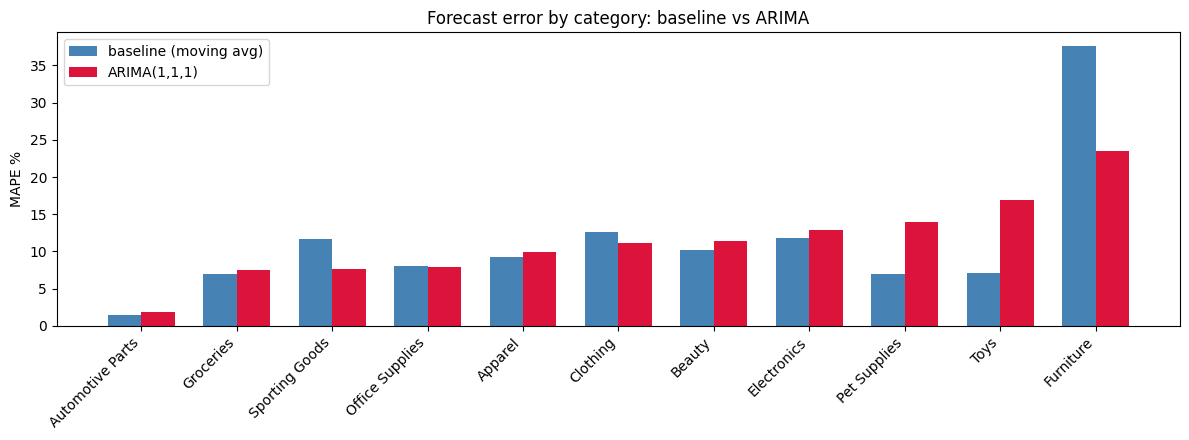

In [5]:
order = scores.sort_values('MAPE_arima')
x = np.arange(len(order))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(x - width/2, order['MAPE_baseline'], width, label='baseline (moving avg)', color='steelblue')
ax.bar(x + width/2, order['MAPE_arima'], width, label='ARIMA(1,1,1)', color='crimson')
ax.set_xticks(x)
ax.set_xticklabels(order['product_category'], rotation=45, ha='right')
ax.set_ylabel('MAPE %')
ax.set_title('Forecast error by category: baseline vs ARIMA')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Visualize both forecasts against actuals for one category

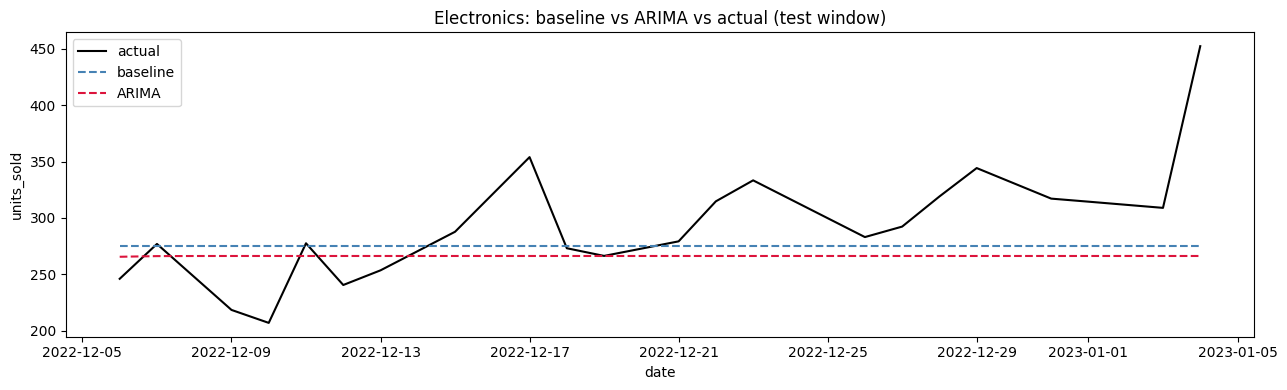

In [6]:
SAMPLE_CAT = 'Electronics'
sub = combined[combined['product_category'] == SAMPLE_CAT].sort_values('date')

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(sub['date'], sub[TARGET], color='black', lw=1.5, label='actual')
ax.plot(sub['date'], sub['forecast_ma'], color='steelblue', lw=1.5, ls='--', label='baseline')
ax.plot(sub['date'], sub['forecast_arima'], color='crimson', lw=1.5, ls='--', label='ARIMA')
ax.set_title(f'{SAMPLE_CAT}: baseline vs ARIMA vs actual (test window)')
ax.set_xlabel('date'); ax.set_ylabel(TARGET); ax.legend()
plt.tight_layout()
plt.show()

## 5. Save the comparison table

In [7]:
OUT_PATH = Path('..') / 'data' / 'processed' / 'model_comparison.csv'
scores.to_csv(OUT_PATH, index=False)
print('Saved comparison table ->', OUT_PATH)

Saved comparison table -> ../data/processed/model_comparison.csv


## 6. Summary

ARIMA is compared against the moving-average baseline on identical 30-day
held-out windows, per category, using MAPE and RMSE. The comparison table
(`data/processed/model_comparison.csv`) and the bar chart above show exactly
where ARIMA earns its complexity and where the flat baseline is still
competitive — that's the evidence to bring into the Week 4 dashboard and the
final write-up.
